<a href="https://colab.research.google.com/github/KevinParker02/Colab-M.L-/blob/Colab/PokemonA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

Importamos el csv de los datos de pokemon para ver la tablas y su posterior análisis

In [ ]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    name=fn
df = pd.read_csv(name, sep=",")
df.head(799)

Saving Pokemon.csv to Pokemon.csv


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,718,Zygarde50% Forme,Dragon,Ground,600,108,100,121,81,95,95,6,True
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True


En la tabla se puede ver como entidades el nombre del pokemon, tipo, total de todas las estadísticas y otros poderes de cada pokemón

In [ ]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


Eliminamos algunas columnas que no son necesarias para el análisis

In [ ]:
PokeNew = df.drop(['Sp. Atk','Sp. Def','Speed'], axis = 'columns')
PokeNew.describe()

,#,Total,HP,Attack,Defense,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,6.00000


Volvemos a mostrar los datos sin las columnas innecesarias.

In [ ]:
PokeNew.head(799)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,1,False
...,...,...,...,...,...,...,...,...,...,...
794,718,Zygarde50% Forme,Dragon,Ground,600,108,100,121,6,True
795,719,Diancie,Rock,Fairy,600,50,100,150,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,6,True


Ahora sacaremos la Media (promedio) de todos los Pokemones y del HP:

In [ ]:
PokeNew['Total'].mean().round(0)

np.float64(435.0)

In [ ]:
PokeNew['HP'].mean().round(0)

np.float64(69.0)

Ahora se calculará la mediana (50%) del ataque y de la defensade los pokemones

In [ ]:
PokeNew['Attack'].median()

75.0

In [ ]:
PokeNew['Defense'].median()

70.0

Ahora se calculará la moda (dato que más se repite) del total de pokemones

In [ ]:
PokeNew['Total'].mode()

,Total
0,600


Se calcula la Desviación Estándar

In [ ]:
PokeNew['Total'].std()

119.963039755519

Se calcula la Varianza

In [ ]:
PokeNew['Total'].var()

14391.130907384233



---



GRÁFICOS

In [ ]:
def bar_plot(variable):
    """
        input: variable ex: "Sex"
        output: bar plot & value count
    """
    # get feature
    var = df[variable]
    # count number of categorical variable(value/sample)
    varValue = var.value_counts()

    # visualize
    plt.figure(figsize = (9,3))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))

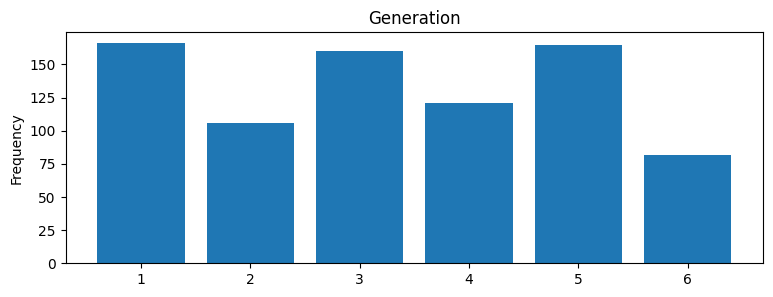

Generation: 
 Generation
1    166
5    165
3    160
4    121
2    106
6     82
Name: count, dtype: int64


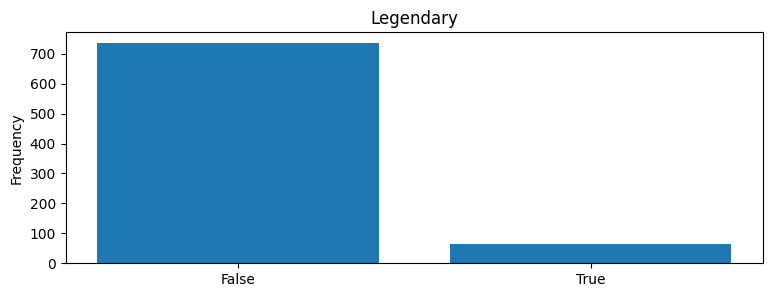

Legendary: 
 Legendary
False    735
True      65
Name: count, dtype: int64


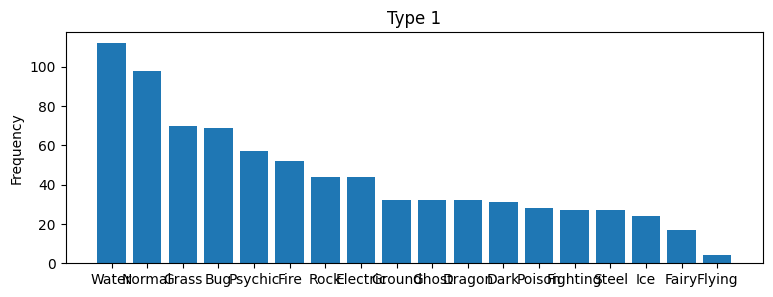

Type 1: 
 Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Rock         44
Electric     44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64


In [ ]:
category1 = ["Generation","Legendary","Type 1"]
for c in category1:
    bar_plot(c)

PARTE 2 HISTOGRAMASSSS AAAAAAAAAAAAAAAAAAAAAAAAA

In [ ]:
def plot_hist(variable):
    plt.figure(figsize = (9,3))
    plt.hist(df[variable], bins = 50)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist".format(variable))
    plt.show()

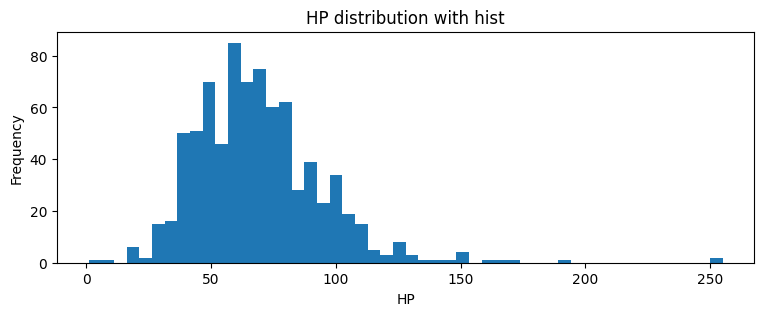

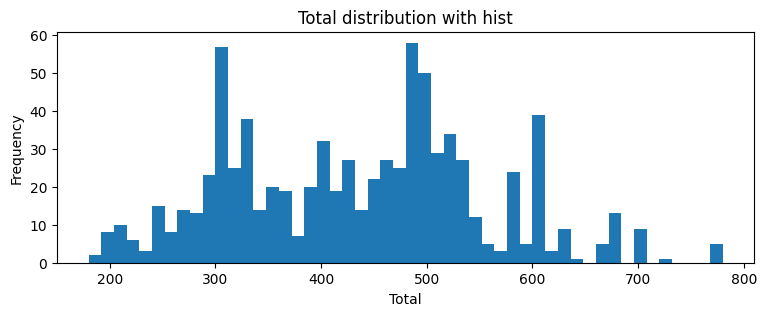

In [ ]:
numericVar = ["HP","Total"]
for n in numericVar:
    plot_hist(n)

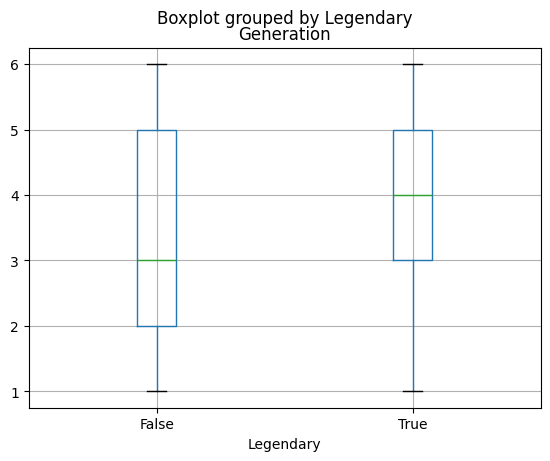

In [ ]:
df.boxplot(column="Generation",by = "Legendary")
plt.show()

Parte 3 Gráficos

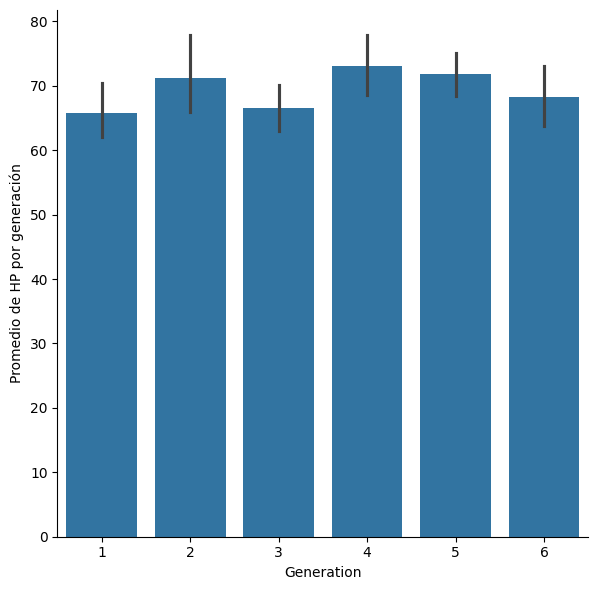

In [ ]:
g = sns.catplot(x = "Generation", y = "HP", data = df, kind = "bar", height=6)
g.set_ylabels("Promedio de HP por generación")
plt.show()

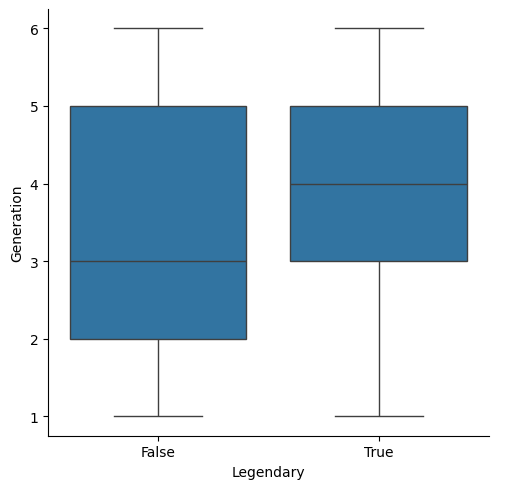

In [ ]:
sns.catplot(x = "Legendary", y = "Generation", data = df, kind = "box")
plt.show()

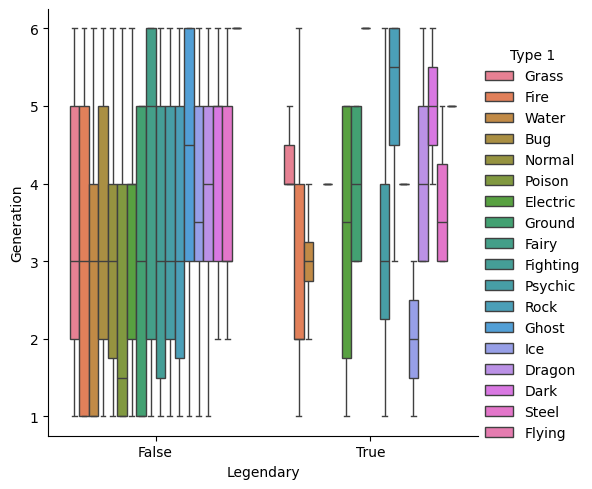

In [ ]:
sns.catplot(x = "Legendary", y = "Generation", hue = "Type 1",data = df, kind = "box")
plt.show()